In [1]:
%load_ext autoreload
%autoreload 2

In [4]:
!pip install numpy

In [5]:
# !pip install -U bitsandbytes

In [1]:
import numpy as np
from datasets import load_dataset
import numpy as np
import torch.nn.functional as F
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

In [2]:
from backtracking_data_sampling import *

In [3]:
unique_uuids_debug = {'167ecbbb-4270-534f-afa5-75d01d968ab5',
 '1cd82e3d-2e7a-5eca-9571-62f5669824c4',
 '1d57f4b3-c516-5522-91cc-a60dd91f6f66',
 '2a4c0374-d9ea-538e-8e0f-0811359d6cf6', #12 waits 9 without space 3 with space
 '39a6c760-dfa3-5201-aa87-105127951e16',
 '4cb423e0-0c1b-5c53-943d-58dadc0e8955',
 '586fd646-76d6-5070-8c81-9993ab9d8559',
 '7721db8b-0313-545f-a292-7116ab4a5ec3',
 '79e837be-2801-5a6a-bc7a-0acee3cdd5fd',
 '84f224e8-719b-5b42-a410-27816014bdd3',
 '9224d27e-798f-569e -a808-122e2d76c789',
 '96c9bf5f-cffe-505b-80c0-e679e10d2cf9',
 'a583d65c-9b4c-56ce-8263-47edbc22baa3',
 'bdcc2598-b04d-5cb8-8634-d35d03fc6bf2',
 'ea24dff6-9e4d-5c55-9ec0-c4d55424997a',
 'f769fc87-fed5-5b73-8403-372cdd409800'}


In [4]:
df_exploded = pd.read_pickle("openr1_math_with_cot_cues.pkl")

In [6]:
df_exploded["prefill"][2]

'Prove that number $1$ can be represented as a sum of a finite number $n$ of real numbers, less than $1,$ not necessarily  distinct, which contain in their decimal representation only the digits $0$ and/or $7.$ Which is the least possible number $n$?\nPlease reason step by step, and put your final answer within \\boxed{}.\n<think>\nOkay, so the problem is to prove that the number 1 can be represented as a sum of a finite number n of real numbers, each less than 1, where each number in the sum has a decimal representation consisting only of the digits 0 and/or 7. And then we need to find the least possible n.\n\nFirst, let me make sure I understand the problem correctly. We need to find the smallest n such that there exist numbers a_1, a_2, ..., a_n, each less than 1, and each a_i has a decimal expansion with only 0s and 7s. When we add these numbers together, the sum is exactly 1.\n\nHmm. So each of these numbers is like 0.7, 0.07, 0.777, 0.0707, etc. But each must be less than 1, so n

In [19]:
df_exploded[df_exploded["correctness_count"] == 1]["prefill"][0]

'## Task B-1.3.\n\nA ship traveling along a river has covered $24 \\mathrm{~km}$ upstream and $28 \\mathrm{~km}$ downstream. For this journey, it took half an hour less than for traveling $30 \\mathrm{~km}$ upstream and $21 \\mathrm{~km}$ downstream, or half an hour more than for traveling $15 \\mathrm{~km}$ upstream and $42 \\mathrm{~km}$ downstream, assuming that both the ship and the river move uniformly.\n\nDetermine the speed of the ship in still water and the speed of the river.\nPlease reason step by step, and put your final answer within \\boxed{}.\n<think>\nOkay, so I need to find the speed of the ship in still water and the speed of the river. Let me start by recalling that when a ship is moving upstream, its effective speed is the speed of the ship minus the speed of the river. Conversely, when moving downstream, its effective speed is the ship\'s speed plus the river\'s speed. \n\nLet me denote the speed of the ship in still water as \\( v \\) (in km/h) and the speed of the

In [14]:
df_exploded["prefill"][92114]

'6) What is the value of the square of the square of the square of 8?\n(A) $2^{8}$\n$\\begin{array}{ll}\\text { (B) } 8^{4} & \\text { (C) } 8^{6}\\end{array}$\n(D) $8^{8}$\n(E) $2^{64}$.\nPlease reason step by step, and put your final answer within \\boxed{}.\n<think>\nOkay, let\'s see. The problem is asking for the value of the square of the square of the square of 8. Hmm, that sounds a bit complicated, but maybe if I break it down step by step, it\'ll make more sense. \n\nFirst, let me make sure I understand the wording correctly. "The square of the square of the square of 8." So that means I need to take 8, square it, then take that result and square it again, and then take that result and square it once more? So, like three squarings in total? Let me verify that interpretation.\n\nIf I parse the phrase: "square of the square of the square of 8." The innermost part is "square of 8," which is 8 squared. Then the next layer is "square of [square of 8]," which would be (8 squared) squ

## Collect Activations Data

In [6]:
len(df_exploded)

92119

In [12]:
# MODEL_NAME = "Qwen/QwQ-32B-Preview"
MODEL_NAME = "deepseek-ai/DeepSeek-R1-Distill-Llama-8B"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    device_map="cuda:0",
    quantization_config=BitsAndBytesConfig(
        load_in_8bit=True,
    ),
)
model.eval()


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(128256, 4096)
    (layers): ModuleList(
      (0-31): 32 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear8bitLt(in_features=4096, out_features=4096, bias=False)
          (k_proj): Linear8bitLt(in_features=4096, out_features=1024, bias=False)
          (v_proj): Linear8bitLt(in_features=4096, out_features=1024, bias=False)
          (o_proj): Linear8bitLt(in_features=4096, out_features=4096, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear8bitLt(in_features=4096, out_features=14336, bias=False)
          (up_proj): Linear8bitLt(in_features=4096, out_features=14336, bias=False)
          (down_proj): Linear8bitLt(in_features=14336, out_features=4096, bias=False)
          (act_fn): SiLU()
        )
        (input_layernorm): LlamaRMSNorm((4096,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((4096,), eps=1e-05)
      )
    )
    (norm): Lla

In [8]:
# import nltk
# nltk.download('punkt_tab')

In [11]:
!nvidia-smi

Sun Apr 13 19:30:09 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.144.03             Driver Version: 550.144.03     CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          On  |   00000000:10:1C.0 Off |                    0 |
| N/A   43C    P0             77W /  400W |    9397MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [10]:
import gc
import torch

# Clear PyTorch cache
for i in range(torch.cuda.device_count()):
    with torch.cuda.device(i):
        torch.cuda.empty_cache()

gc.collect()


121

In [33]:
del model
torch.cuda.empty_cache()
gc.collect()


0

In [ ]:
from backtracking_data_sampling import *
relevant_cues = [" Wait", "Wait"]

STEP_BY_STEP_SUFFIX = (
    "\nPlease reason step by step, and put your final answer within \\boxed{}.\n"
)

count = 0
activations_data = []

count = 0
# Iterate over each row in the DataFrame
for index, row in df_exploded.iterrows():
    # if row["uuid"] in unique_uuids_evan:
    activations_data.extend(process_samples(row, tokenizer, relevant_cues, model))
    count +=1 
    if count > 1000:
        break

Found 2 potential cue indices
Found 24 potential cue indices
Found 84 potential cue indices
Found 4 potential cue indices
Found 8 potential cue indices
Found 116 potential cue indices
Found 12 potential cue indices
Found 44 potential cue indices
Found 16 potential cue indices
Found 62 potential cue indices
Found 32 potential cue indices
Found 42 potential cue indices
Found 12 potential cue indices
Found 8 potential cue indices
Found 34 potential cue indices
Found 18 potential cue indices
Found 76 potential cue indices
Found 18 potential cue indices
Found 6 potential cue indices
Found 10 potential cue indices
Found 42 potential cue indices
Found 6 potential cue indices
Found 16 potential cue indices
Found 14 potential cue indices
Found 6 potential cue indices
Found 10 potential cue indices
Found 54 potential cue indices
Found 126 potential cue indices
Found 6 potential cue indices
Found 76 potential cue indices
Found 10 potential cue indices
Found 20 potential cue indices
Found 14 poten

Token indices sequence length is longer than the specified maximum sequence length for this model (16652 > 16384). Running this sequence through the model will result in indexing errors


Found 120 potential cue indices
Found 26 potential cue indices
Found 26 potential cue indices
Found 24 potential cue indices
Found 88 potential cue indices
Found 14 potential cue indices
Found 56 potential cue indices
Found 18 potential cue indices
Found 22 potential cue indices
Found 66 potential cue indices
Found 26 potential cue indices
Found 12 potential cue indices
Found 6 potential cue indices
Found 0 potential cue indices
Found 8 potential cue indices
Found 2 potential cue indices
Found 6 potential cue indices
Found 32 potential cue indices
Found 72 potential cue indices
Found 16 potential cue indices
Found 56 potential cue indices
Found 122 potential cue indices
Found 6 potential cue indices
Found 64 potential cue indices
Found 62 potential cue indices
Found 10 potential cue indices
Found 76 potential cue indices
Found 178 potential cue indices
Found 4 potential cue indices
Found 58 potential cue indices
Found 8 potential cue indices
Found 36 potential cue indices
Found 98 pote

In [ ]:
len(activations_data)

In [ ]:
# We take the first 10 from each prefill
def collect_relevant_activations(activations_data, tokenizer, max_per_uuid=10):
    """
    Collects activations from each layer for backtracking and non-backtracking sentences.
    
    Returns:
        activations_dict = {
            "backtracking": [{layer_1: activations, layer_2: activations, ...}],
            "non_backtracking": [{layer_1: activations, layer_2: activations, ...}]
        }
    """
    activations_dict = {"backtracking": defaultdict(list), "non_backtracking": defaultdict(list)}
    
    # Track how many activations are collected per UUID
    backtracking_counts = defaultdict(int)
    non_backtracking_counts = defaultdict(int)
    
    for data in activations_data:
        cue_start = data["cue_start"]
        determining_token_index = data["determining_token_index"]
        cot_cue_value = data["cot_cue_value"]
        cot_cue_token_id = data["cot_cue_token_id"]
        tokens_of_interest = data["tokens_of_interest"]
        relevant_probabilities = data["relevant_probabilities"]
        activations = data["activations"]
        sentence_start = data["sentence_start"]
        uuid = data["uuid"]

        if cot_cue_value:
            cue_probability = relevant_probabilities[cot_cue_token_id]
            # print(cot_cue_value, cot_cue_token_id, cue_probability.item())
            if cue_probability.item() > 0.5 and backtracking_counts[uuid] < max_per_uuid:
                for layer, activation in activations.items():
                    activations_dict["backtracking"][layer].append(activation[1]) 

        else:
            sum_of_relevant_probabilities = sum(relevant_probabilities[i] for i in relevant_probabilities)
            if sum_of_relevant_probabilities < .001 and non_backtracking_counts[uuid] < max_per_uuid:
                for layer, activation in activations.items():
                    activations_dict["non_backtracking"][layer].append(activation[1])  # Activation at token index 1

    return activations_dict

relevant_activations = collect_relevant_activations(activations_data, tokenizer, max_per_uuid=20)

In [ ]:
len(relevant_activations["backtracking"][0]), len(relevant_activations["non_backtracking"][0])

In [19]:
from collections import defaultdict, OrderedDict
import torch

#norm_scores will reflect the true strength of the backtracking signal at each layer — not just 1s.


# Use the activations_dict returned by your function
back = relevant_activations["backtracking"]
non_back = relevant_activations["non_backtracking"]

steering_vectors = {}
mean_scores = {}
norm_scores = {}

for layer in back.keys():
    back_acts = torch.tensor(back[layer])        # [N, d_model]
    non_back_acts = torch.tensor(non_back[layer])  # [M, d_model]

    back_mean = back_acts.mean(dim=0)
    non_back_mean = non_back_acts.mean(dim=0)

    raw_vec = back_mean - non_back_mean
    vec = raw_vec / vec.norm()

    steering_vectors[layer] = vec
    mean_scores[layer] = abs(vec.mean().item())
    # norm_scores[layer] = vec.norm().item()
    norm_scores[layer] = raw_vec.norm().item()  # <-- this line changed



In [20]:
# Rank layers by each metric
ranked_by_mean = OrderedDict(sorted(mean_scores.items(), key=lambda x: x[1], reverse=True))
ranked_by_norm = OrderedDict(sorted(norm_scores.items(), key=lambda x: x[1], reverse=True))

# Show top ranked layers
print(f"{'Rank':<5} {'By abs(mean)':<20} {'Score':<10} || {'By norm':<20} {'Score'}")
print("=" * 70)

for i, ((l1, m_score), (l2, n_score)) in enumerate(zip(ranked_by_mean.items(), ranked_by_norm.items())):
    print(f"{i+1:<5} Layer {l1:<13} {m_score:<10.6f} || Layer {l2:<13} {n_score:.6f}")


Rank  By abs(mean)         Score      || By norm              Score
1     Layer 31            0.004147   || Layer 31            44.218750
2     Layer 30            0.003040   || Layer 30            34.187500
3     Layer 28            0.001842   || Layer 29            30.640625
4     Layer 29            0.001819   || Layer 28            28.125000
5     Layer 26            0.001401   || Layer 27            26.156250
6     Layer 10            0.001173   || Layer 26            24.500000
7     Layer 24            0.001040   || Layer 25            23.140625
8     Layer 13            0.001032   || Layer 24            22.125000
9     Layer 25            0.000967   || Layer 23            20.687500
10    Layer 27            0.000936   || Layer 22            19.546875
11    Layer 12            0.000889   || Layer 21            17.890625
12    Layer 11            0.000800   || Layer 20            16.250000
13    Layer 14            0.000792   || Layer 19            14.734375
14    Layer 22        

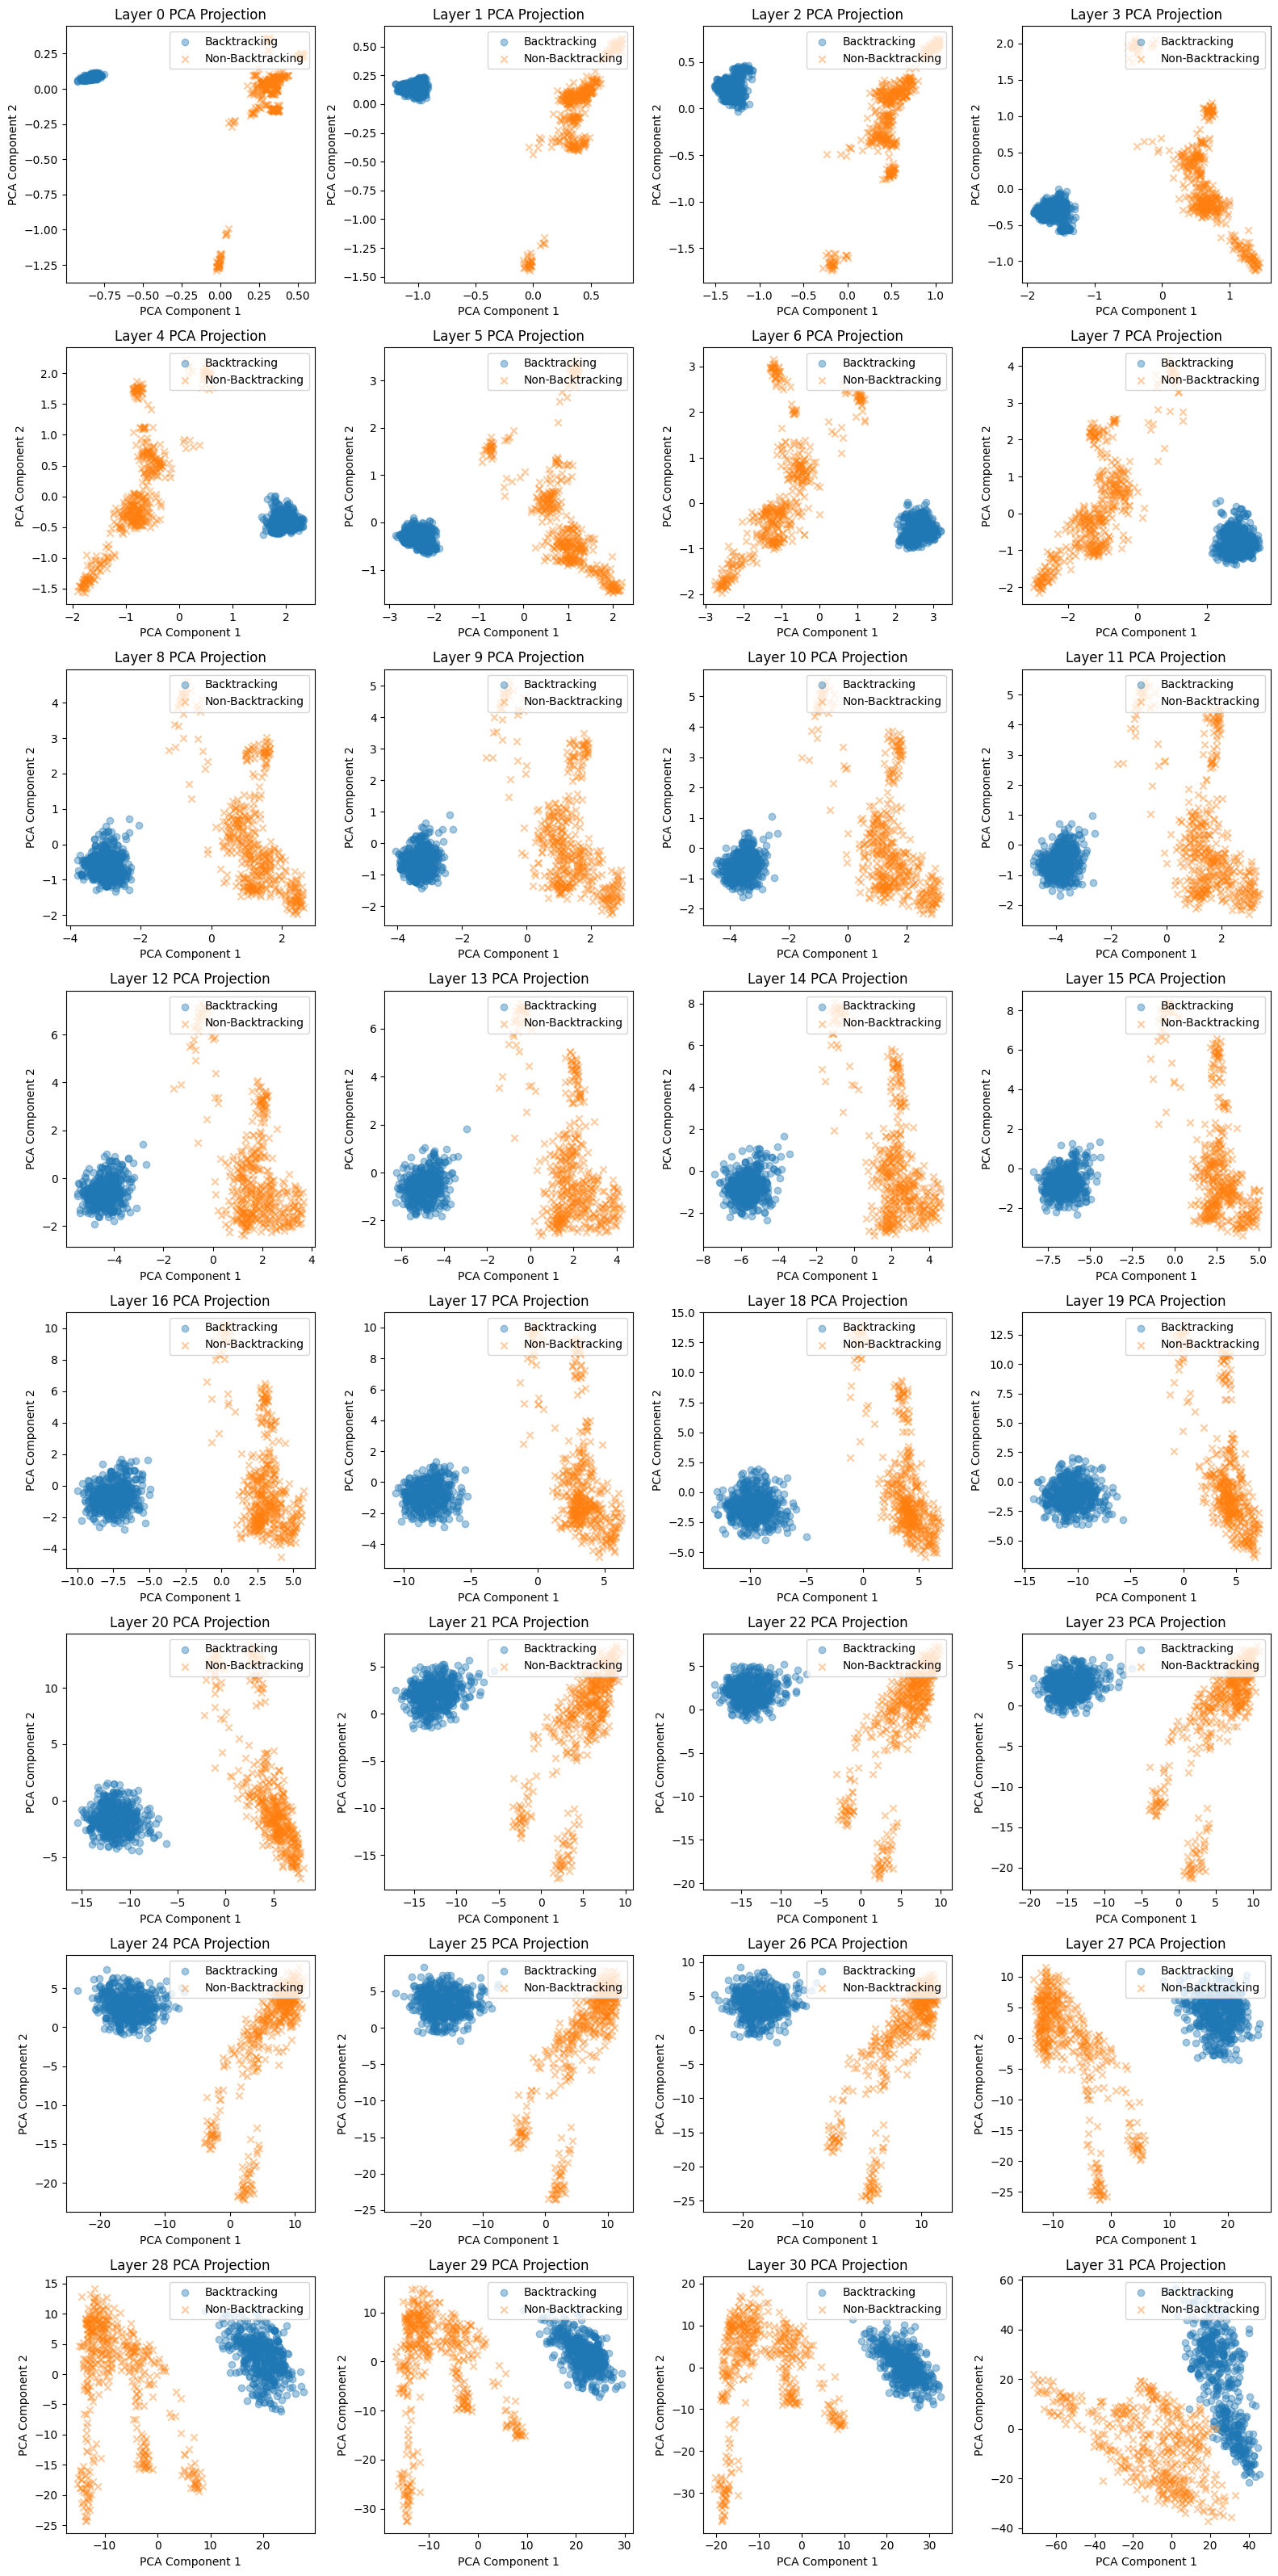

In [ ]:
# Placeholder data (Re-create activations for demonstration)
LAYERS = list(range(0, 32))  # Simulate 31 layers
num_samples = 100  # Number of samples per category
feature_dim = 4096  # Feature dimension

# Generate synthetic activations for backtracking and non-backtracking samples
backtracking_activations = relevant_activations["backtracking"]
non_backtracking_activations = relevant_activations["non_backtracking"]

# Determine grid size for plotting
num_cols = 4  # Set 4 columns
num_rows = (len(LAYERS) + num_cols - 1) // num_cols  # Calculate required rows

# Create figure and axes
fig, axes = plt.subplots(num_rows, num_cols, figsize=(16, 32))
axes = axes.flatten()  # Flatten for easy iteration

# Perform PCA and plot results per layer
for idx, layer in enumerate(LAYERS):
    ax = axes[idx]

    # Get activations for PCA
    activations_backtracking = backtracking_activations[layer][:]
    activations_non_backtracking = non_backtracking_activations[layer]

    num_backtracking = len(activations_backtracking)
    num_nonbacktracking = len(activations_non_backtracking)
    pca = PCA(n_components=2)
    pca_data = np.vstack((activations_non_backtracking, activations_backtracking))
    pca_result = pca.fit_transform(pca_data)

    pca_result_backtracking = pca_result[num_nonbacktracking: , :][:500]
    pca_result_non_backtracking = pca_result[: num_nonbacktracking, :][:500]

    ax.scatter(pca_result_backtracking[:, 0], pca_result_backtracking[:, 1], alpha=0.4, label="Backtracking", marker="o",color="#1f77b4")
    ax.scatter(pca_result_non_backtracking[:, 0], pca_result_non_backtracking[:, 1], alpha=0.4, label="Non-Backtracking", marker="x", color="#ff7f0e")
    ax.set_title(f"Layer {layer} PCA Projection")
    ax.set_xlabel("PCA Component 1")
    ax.set_ylabel("PCA Component 2")
    ax.legend(loc="upper right")

# Remove empty subplots if any
for i in range(len(LAYERS), len(axes)):
    fig.delaxes(axes[i])

# Adjust layout and show
plt.tight_layout()
plt.savefig("pca_activations_wait.png", dpi=300, bbox_inches="tight")
plt.show()


## Compute Steering Vectors, "Backtracking Direction"

Enhance backtracking: Add +steering_vector   
Reduce backtracking: Subtract -steering_vector

In [ ]:
def compute_steering_vector(activations_dict):
    steering_vectors = {}
    for layer in activations_dict["backtracking"]:
        backtracking_activations = [torch.tensor(a) if isinstance(a, np.ndarray) else a for a in activations_dict["backtracking"][layer]]
        non_backtracking_activations = [torch.tensor(a) if isinstance(a, np.ndarray) else a for a in activations_dict["non_backtracking"][layer]]

        backtracking_activations = torch.stack(backtracking_activations)  
        non_backtracking_activations = torch.stack(non_backtracking_activations)  

        mean_backtracking = backtracking_activations.mean(dim=0)  
        mean_non_backtracking = non_backtracking_activations.mean(dim=0)  

        steering_vectors[layer] = mean_backtracking - mean_non_backtracking  

    return steering_vectors

# Compute the steering vectors
steering_vectors = compute_steering_vector(relevant_activations)
# Save to disk
torch.save(steering_vectors, "steering_vectors_Wait_prev_index.pt")



Next, we compute the steering vectors at different sample sizes and analyze their cosine similarity trends across layers. This will help visualize how the steering vector stabilizes as we increase the number of samples.Below we compute and compar steering vectors across different sample sizes using cosine similarity to evaluate how well the computed vector from a subset of data aligns with the vector computed using all available data.


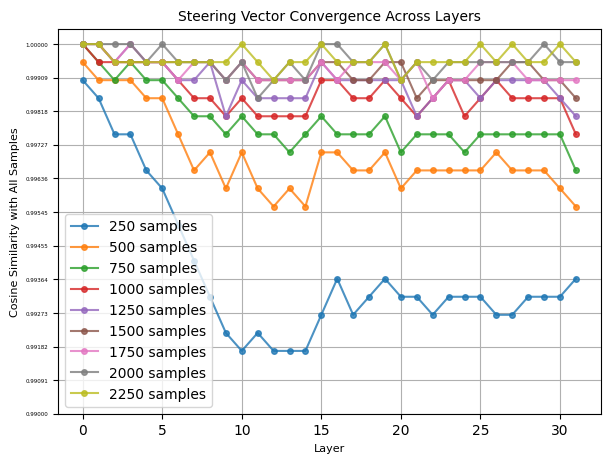

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# Define the sample sizes to test
sample_sizes = [250*i for i in range(1,10)] + ["all"]

def compute_steering_vector(activations_dict, sample_size=None):
    """
    Computes the steering vector using a subset of the data.
    If sample_size is None or "all", use all available data.
    """
    steering_vectors = {}
    for layer in activations_dict["backtracking"]:
        backtracking_activations = activations_dict["backtracking"][layer]
        non_backtracking_activations = activations_dict["non_backtracking"][layer]

        # Convert to tensors if needed
        backtracking_activations = [torch.tensor(a) if isinstance(a, np.ndarray) else a for a in backtracking_activations]
        non_backtracking_activations = [torch.tensor(a) if isinstance(a, np.ndarray) else a for a in non_backtracking_activations]

        # Apply sample size limit if specified
        if sample_size != "all":
            backtracking_activations = backtracking_activations[:sample_size]
            non_backtracking_activations = non_backtracking_activations[:sample_size]

        # Stack and compute means
        backtracking_activations = torch.stack(backtracking_activations)  
        non_backtracking_activations = torch.stack(non_backtracking_activations)  

        mean_backtracking = backtracking_activations.mean(dim=0)  
        mean_non_backtracking = non_backtracking_activations.mean(dim=0)  

        # Compute steering vector
        steering_vectors[layer] = mean_backtracking - mean_non_backtracking  

    return steering_vectors

# Compute the reference steering vector using all samples
steering_vector_all = compute_steering_vector(relevant_activations, sample_size="all")

# Store results for visualization
cosine_similarities = {size: {} for size in sample_sizes[:-1]}  # Exclude "all" since it's the reference

for sample_size in sample_sizes[:-1]:  # Exclude "all"
    steering_vector_sample = compute_steering_vector(relevant_activations, sample_size=sample_size)
    
    for layer in steering_vector_all:
        if layer in steering_vector_sample:
            # Flatten vectors for comparison
            vec_sample = steering_vector_sample[layer].flatten()
            vec_all = steering_vector_all[layer].flatten()

            # Compute cosine similarity
            cosine_sim = torch.nn.functional.cosine_similarity(vec_sample, vec_all, dim=0).item()
            
            cosine_similarities[sample_size][layer] = cosine_sim  # Store result

# Plot cosine similarities per layer
plt.figure(figsize=(7, 5))
# color_palette = plt.get_cmap("tab10")

for sample_size, layer_similarities in cosine_similarities.items():
    layers = sorted(layer_similarities.keys())
    similarities = [layer_similarities[layer] for layer in layers]
    # plt.plot(layers, similarities, label=f"{sample_size} samples")
    plt.plot(layers, similarities, marker='o', linestyle='-', markersize=4, label=f"{sample_size} samples", alpha=0.8)


# More granular y-ticks (example: from 0.9 to 1.0 in small steps)
plt.yticks(np.linspace(0.99, 1.0, 12), fontsize=4)  # Adjust as needed


# Reduce font sizes for better readability
plt.xlabel("Layer", fontsize=8)  # Smaller font for x-axis label
plt.ylabel("Cosine Similarity with All Samples", fontsize=8)  # Smaller font for y-axis label
plt.title("Steering Vector Convergence Across Layers", fontsize=10)  # Smaller font for title

plt.savefig("steering_vector_Wait_convergence2.png", dpi=300, bbox_inches="tight")


plt.legend()
plt.grid(True)
plt.show()


## Evaluate Applying Steering Vectors

In [ ]:
import pandas as pd

# Load the Parquet file
# file_path = "/home/ubuntu/cot-reasoning/llama_steering_wait/steering_Wait_R1-Distill-Llama-8B_190.parquet"
file_path = "/home/ubuntu/cot-reasoning/llama_steering_wait_16k/steering_Wait_R1-Distill-Llama-8B_1000.parquet"
df = pd.read_parquet(file_path)

# Display dataset info
df.head()

""


In [ ]:
# Load OpenR1-Math-220k Dataset
math_data = load_dataset("open-r1/OpenR1-Math-220k", split="train")

# Convert dataset to Pandas DataFrame
math_df = math_data.to_pandas()

Resolving data files:   0%|          | 0/20 [00:00<?, ?it/s]

In [ ]:
# Keep only the `uuid`, `input_text`, and `answer` columns
math_df = math_df[["uuid", "answer"]]


In [ ]:
df = df.merge(math_df, on=["uuid"], how="left")


In [ ]:
df["uuid"][0], df["answer"][0]

('78b0db16-409f-5e5d-9861-d426afbf5dc6', '13.7')

In [ ]:
df_exploded[df_exploded["uuid"] == '78b0db16-409f-5e5d-9861-d426afbf5dc6']["prefill"].iloc[0]

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Assume your DataFrame is called df

# Count occurrences of "Wait" in each output column
df["baseline_wait"] = df["baseline"].str.count("Wait")
df["backtracking_wait"] = df["backtracking"].str.count("Wait")
df["anti_wait"] = df["anti_backtracking"].str.count("Wait")

# Quick sanity check
df[["baseline_wait", "backtracking_wait", "anti_wait"]].head(10)


,baseline_wait,backtracking_wait,anti_wait
0,19,16,10
1,14,16,17
2,13,22,14
3,11,12,7
4,14,22,9
5,10,17,15
6,25,19,14
7,16,19,8
8,19,12,18
9,15,11,14


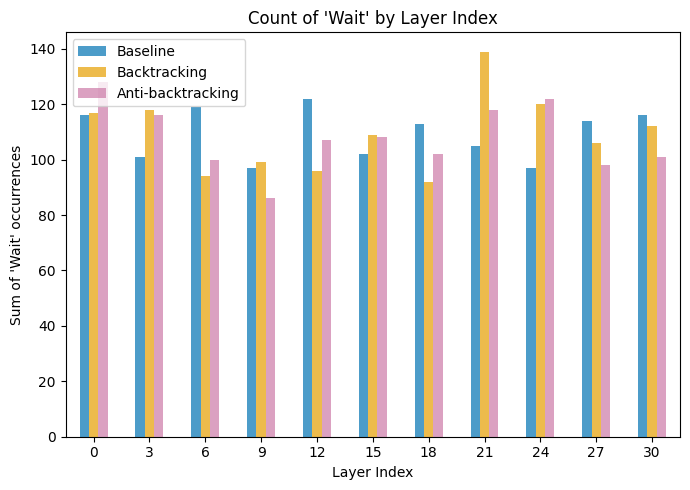

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# We'll assume you already have columns like this:
# df["baseline_wait"] = df["baseline"].str.count("Wait")
# df["backtracking_wait"] = df["backtracking"].str.count("Wait")
# df["anti_wait"] = df["anti_backtracking"].str.count("Wait")

# 1) Group by layer_index and aggregate the sum of Wait counts
grouped = df.groupby("layer_index").agg({
    "baseline_wait": "sum",
    "backtracking_wait": "sum",
    "anti_wait": "sum"
}).reset_index()

# 2) Create a grouped bar chart
#   Each row in 'grouped' is one layer_index,
#   and the columns are the total "Wait" counts for each approach.
ax = grouped.plot(
    x="layer_index",
    y=["baseline_wait", "backtracking_wait", "anti_wait"],
    kind="bar",
    rot=0,
    figsize=(7, 5),
    alpha=0.7,
    color=["#0072B2", "#E69F00", "#CC79A7"]  
)

plt.title("Count of 'Wait' by Layer Index")
plt.xlabel("Layer Index")
plt.ylabel("Sum of 'Wait' occurrences")
plt.legend(["Baseline", "Backtracking", "Anti-backtracking"], loc="best")
plt.tight_layout()
plt.show()


In [ ]:
grouped

,layer_index,baseline_wait,backtracking_wait,anti_wait
0,0,116,117,128
1,3,101,118,116
2,6,119,94,100
3,9,97,99,86
4,12,122,96,107
5,15,102,109,108
6,18,113,92,102
7,21,105,139,118
8,24,97,120,122
9,27,114,106,98


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set the styling for a more modern look
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("viridis")

def plot_wait_counts(df, figsize=(8, 6), save_path=None):
    """
    Creates an improved visualization of 'Wait' counts by layer index.
    
    Args:
        df: DataFrame with columns 'layer_index', 'baseline_wait', 'backtracking_wait', 'anti_wait'
        figsize: Size of the figure (width, height)
        save_path: Optional path to save the figure
    """
    # Group by layer_index and aggregate the sum of Wait counts
    grouped = df.groupby("layer_index").agg({
        "baseline_wait": "sum",
        "backtracking_wait": "sum",
        "anti_wait": "sum"
    }).reset_index()
    
    # Remove layer 0 and sort by layer index
    grouped = grouped[grouped['layer_index'] > 0].sort_values('layer_index')
    
    # Calculate the difference from baseline for better comparison
    grouped['backtracking_diff'] = grouped['backtracking_wait'] - grouped['baseline_wait']
    grouped['anti_diff'] = grouped['anti_wait'] - grouped['baseline_wait']
    
    # Create figure with two subplots side by side
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize, gridspec_kw={'width_ratios': [1, 1.2]})
    
    # Custom colors with good contrast
    colors = ['#2D6A9F', '#993399', '#FF8C00']
    
    # Plot 1: Absolute counts
    bars = grouped.plot(
        x="layer_index",
        y=["baseline_wait", "backtracking_wait", "anti_wait"],
        kind="bar",
        rot=0,
        ax=ax1,
        color=colors,
        alpha=0.5,
        width=0.8
    )
    
    # Add value labels on top of bars
    for container in bars.containers:
        ax1.bar_label(container, fmt='%d', fontsize=8, padding=3)
    
    ax1.set_title("Absolute Count of 'Wait' by Layer", fontsize=8, fontweight='bold')
    ax1.set_xlabel("Layer Index", fontsize=8)
    ax1.set_ylabel("Number of 'Wait' Occurrences", fontsize=8)
    ax1.legend(["Baseline", "Towards Backtracking", "Away"], 
              fontsize=8, loc="upper right", framealpha=0.7)
    ax1.grid(axis='y', linestyle='--', alpha=0.7)
    
    # Plot 2: Differences from baseline
    diff_data = pd.melt(
        grouped, 
        id_vars=['layer_index'], 
        value_vars=['backtracking_diff', 'anti_diff'],
        var_name='method', 
        value_name='difference'
    )
    diff_data['color'] = np.where(diff_data['difference'] >= 0, colors[1], colors[2])
    
    # Create a more visually striking difference plot
    barplot = sns.barplot(
        x='layer_index', 
        y='difference', 
        hue='method', 
        data=diff_data,
        ax=ax2,
        palette=[colors[1], colors[2]],
        alpha=0.5
    )
    
    # Fix the legend colors to match the bars
    handles, labels = ax2.get_legend_handles_labels()
    for i, handle in enumerate(handles):
        handle.set_facecolor(colors[i+1])  # Use the same colors as the bars
        handle.set_alpha(0.5)  # Match the alpha of the bars
    
    # Add horizontal line at y=0
    ax2.axhline(y=0, color='black', linestyle='-', alpha=0.3)
    
    # Add value labels on bars
    for i, p in enumerate(ax2.patches):
        height = p.get_height()
        if not np.isnan(height):
            ax2.annotate(
                f'{int(height)}', 
                (p.get_x() + p.get_width() / 2., height),
                ha='center', 
                va='center' if height < 0 else 'bottom',
                fontsize=8,
                xytext=(0, 5 if height >= 0 else -5),
                textcoords='offset points'
            )
    
    ax2.set_title("Difference from Baseline", fontsize=8, fontweight='bold')
    ax2.set_xlabel("Layer Index", fontsize=8)
    ax2.set_ylabel("Change in 'Wait' Occurrences", fontsize=8)
    ax2.legend(
        ["Towards Backtracking", "Away"], 
        fontsize=8,
        loc="upper right",
        framealpha=0.7
    )
    ax2.grid(axis='y', linestyle='--', alpha=0.7)
    
    # Add a combined title
    plt.suptitle("Impact of Steering Vectors on 'Wait' Occurrences by Layer", 
                fontsize=8, fontweight='bold', y=0.98)
    
    # Adjust layout
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    
    # Save if path provided
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    return fig, (ax1, ax2)


(<Figure size 800x600 with 2 Axes>,
 (<Axes: title={'center': "Absolute Count of 'Wait' by Layer"}, xlabel='Layer Index', ylabel="Number of 'Wait' Occurrences">,
  <Axes: title={'center': 'Difference from Baseline'}, xlabel='Layer Index', ylabel="Change in 'Wait' Occurrences">))

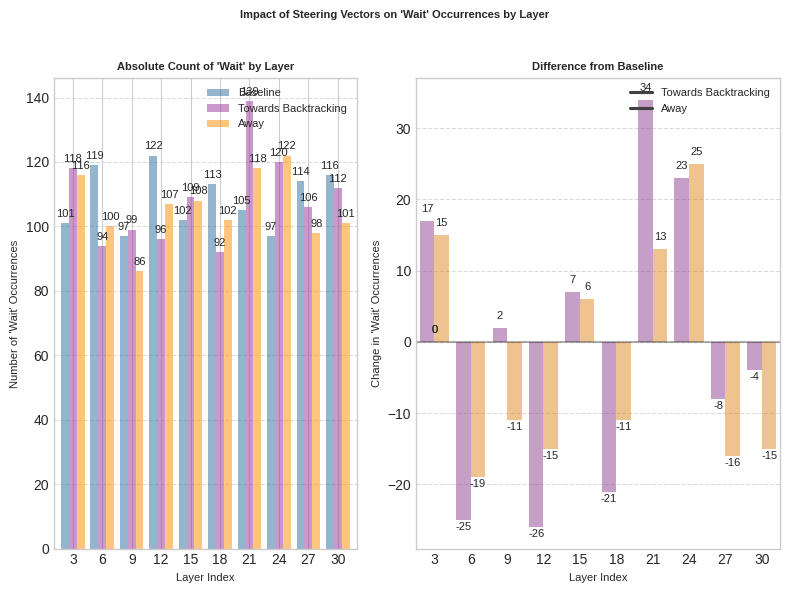

In [ ]:
plot_wait_counts(df)

### Example Steering Vector

In [ ]:
# Define the input text
input_text = """
## Task B-1.3.\n\nA ship traveling along a river has covered $24 \\mathrm{~km}$ upstream and $28 \\mathrm{~km}$ downstream. 
For this journey, it took half an hour less than for traveling $30 \\mathrm{~km}$ upstream and $21 \\mathrm{~km}$ downstream, 
or half an hour more than for traveling $15 \\mathrm{~km}$ upstream and $42 \\mathrm{~km}$ downstream, 
assuming that both the ship and the river move uniformly.\n\nDetermine the speed of the ship in still water and the speed of the river.
\nPlease reason step by step, and put your final answer within \\boxed{}.\n"""


steering_vectors = torch.load("steering_vectors_Wait.pt")
layer_index = selected_layers[0]
# Baseline (no steering)
baseline_output = generate_text(model, tokenizer, input_text)

# Steering Towards Backtracking
backtracking_output = generate_text(model, tokenizer, input_text, 
                                   steering_vector=steering_vectors[5], scale=1.0)

# Steering Away from Backtracking
anti_backtracking_output = generate_text(model, tokenizer, input_text, 
                                        steering_vector=-steering_vectors[5], scale=1.0)

print("=== Baseline ===")
print(baseline_output)
print("\n=== Steering Towards Backtracking ===")
print(backtracking_output)
print("\n=== Steering Away from Backtracking ===")
print(anti_backtracking_output)


Before and after steering, measure how the model assigns probabilities to a cue like "Wait".


In [ ]:
def get_token_probability(model, tokenizer, input_text, target_token):
    """
    Computes probability of a target token appearing in the model's predictions.
    """
    inputs = tokenizer(input_text, return_tensors="pt").to("cuda")

    with torch.no_grad():
        output = model(**inputs)
        logits = output.logits  # Shape: (batch_size, seq_length, vocab_size)

    # Get the last token's logits
    last_token_logits = logits[0, -1, :]  # Shape: (vocab_size,)

    # Convert logits to probabilities
    probs = torch.nn.functional.softmax(last_token_logits, dim=0)

    # Get probability of target token
    target_token_id = tokenizer.convert_tokens_to_ids(target_token)
    target_token_prob = probs[target_token_id].item()

    return target_token_prob

# Compute probabilities for "Wait" before and after steering
baseline_prob = get_token_probability(model, tokenizer, baseline_output, "Wait")
backtracking_prob = get_token_probability(model, tokenizer, backtracking_output, "Wait")
anti_backtracking_prob = get_token_probability(model, tokenizer, anti_backtracking_output, "Wait")

print(f"Baseline 'Wait' Probability: {baseline_prob:.6f}")
print(f"Backtracking 'Wait' Probability: {backtracking_prob:.6f}")
print(f"Anti-Backtracking 'Wait' Probability: {anti_backtracking_prob:.6f}")


Sentence Completion Differences
Look for differences in generated sentences
Does the model change its prediction after applying the steering vector?

To compare token probability distributions before and after steering

In [ ]:
def get_top_k_probabilities(model, tokenizer, input_text, top_k=5):
    """
    Computes the top-k token probabilities after the last token.
    """
    inputs = tokenizer(input_text, return_tensors="pt").to("cuda")

    with torch.no_grad():
        output = model(**inputs)
        logits = output.logits[0, -1, :]  # Last token logits

    # Convert logits to probabilities
    probs = torch.nn.functional.softmax(logits, dim=0)

    # Get the top-k predictions
    top_k_probs, top_k_indices = torch.topk(probs, top_k)

    # Convert indices to tokens
    top_k_tokens = tokenizer.convert_ids_to_tokens(top_k_indices.tolist())

    return list(zip(top_k_tokens, top_k_probs.tolist()))

# Measure before and after steering
baseline_probs = get_top_k_probabilities(model, tokenizer, baseline_output)
backtracking_probs = get_top_k_probabilities(model, tokenizer, backtracking_output)
anti_backtracking_probs = get_top_k_probabilities(model, tokenizer, anti_backtracking_output)

print("Baseline Token Probabilities:", baseline_probs)
print("Backtracking Token Probabilities:", backtracking_probs)
print("Anti-Backtracking Token Probabilities:", anti_backtracking_probs)


In [ ]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

# ------------------
# 1) Define reasoning cues
# ------------------
reasoning_cues = relevant_cues
# Flatten all token IDs for each cue into one big set
reasoning_token_ids = set()
for cue in reasoning_cues:
    token_ids = tokenizer(cue, add_special_tokens=False).input_ids
    for tid in token_ids:
        reasoning_token_ids.add(tid)

# ------------------
# 2) Tokenize your message
# ------------------
message = df["prefill"][index]   # from your example
inputs = tokenizer(message, return_tensors="pt")
input_ids = inputs["input_ids"].to(model.device)

# We'll measure up to the second-to-last token for prefix
seq_len = input_ids.shape[1]

reasoning_probabilities = []
reasoning_positions = []

# ------------------
# 3) Loop over each prefix
# ------------------
for i in range(seq_len - 1):
    # Slice prefix from token 0..i (inclusive)
    prefix_input_ids = input_ids[:, :i+1]

    # Forward pass to get logits for next token
    with torch.no_grad():
        output = model(prefix_input_ids, use_cache=False)
    
    # output.logits has shape [batch_size, seq_len, vocab_size]
    # Here, seq_len = i+1 for the prefix
    next_token_logits = output.logits[0, -1, :]       # shape: [vocab_size]
    next_token_probs = F.softmax(next_token_logits, dim=-1)

    # Sum the probability for all "reasoning" tokens
    sum_reasoning_prob = next_token_probs[list(reasoning_token_ids)].sum().item()
    reasoning_probabilities.append(sum_reasoning_prob)

    # Check if the *actual* token at i+1 is a reasoning token
    # (the next token in the real sequence is input_ids[0, i+1])
    actual_next_token_id = input_ids[0, i+1].item()
    if actual_next_token_id in reasoning_token_ids:
        reasoning_positions.append(i+1)  # store the index where reasoning actually happened

# ------------------
# 4) Plot
# ------------------
plt.figure(figsize=(10, 5))
plt.plot(range(seq_len - 1), reasoning_probabilities, marker='o', label="Prob(Reasoning Token)")
plt.xlabel("Prefix Length (token index)")
plt.ylabel("Sum of next-token probabilities for 'reasoning' tokens")
plt.title("Model's 'desire to reason' over the sequence")

# Highlight the positions where a reasoning token was actually used
for pos in reasoning_positions:
    plt.axvline(pos-1, color='red', linestyle='--', alpha=0.6) 
    # We use pos-1 if we want the line to line up with the prefix index
    # Or just use pos to highlight the exact next token position

plt.legend()
plt.show()


In [ ]:
### Save Abliterated Model



Typically, this intervention is applied to a specific layer, not all layers — particularly the one where the steering direction (like your reasoning direction) was found to have the most impact (e.g., high cosine sim, effect on output, etc.).

Assuming you're working with deepseek-ai/DeepSeek-R1-Distill-Llama-8B, which is a LLaMA-based architecture, you likely want to:

Extract the weight matrix of the MLP and attention outputs at layer 19.
Apply the projection update using your steering_vector (normalized).
Save the model to Hugging Face using model.push_to_hub() or transformers tooling

In [ ]:
# MODEL_NAME = "Qwen/QwQ-32B-Preview"
MODEL_NAME = "deepseek-ai/DeepSeek-R1-Distill-Llama-8B"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    device_map="cuda:5",
    quantization_config=BitsAndBytesConfig(
        load_in_8bit=True,
    ),
)
model.eval()
# Set target device
target_device = torch.device("cuda:5")

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [ ]:
def get_orthogonalized_matrix(W, direction):
    """
    Orthogonalize weight matrix W w.r.t. a direction vector.
    W: torch.Tensor of shape [out_dim, in_dim]
    direction: torch.Tensor of shape [out_dim]
    """
    direction = direction / direction.norm()  # normalize to unit vector
    projection = torch.ger(direction, direction)  # outer product
    return W - torch.mm(projection, W)  # subtract projected part


In [ ]:
print(model.model.layers[19])  # to double check module names


LlamaDecoderLayer(
  (self_attn): LlamaAttention(
    (q_proj): Linear8bitLt(in_features=4096, out_features=4096, bias=False)
    (k_proj): Linear8bitLt(in_features=4096, out_features=1024, bias=False)
    (v_proj): Linear8bitLt(in_features=4096, out_features=1024, bias=False)
    (o_proj): Linear8bitLt(in_features=4096, out_features=4096, bias=False)
  )
  (mlp): LlamaMLP(
    (gate_proj): Linear8bitLt(in_features=4096, out_features=14336, bias=False)
    (up_proj): Linear8bitLt(in_features=4096, out_features=14336, bias=False)
    (down_proj): Linear8bitLt(in_features=14336, out_features=4096, bias=False)
    (act_fn): SiLU()
  )
  (input_layernorm): LlamaRMSNorm((4096,), eps=1e-05)
  (post_attention_layernorm): LlamaRMSNorm((4096,), eps=1e-05)
)


In [ ]:
model.model.layers[19].self_attn.o_proj.weight.data  # Might not even exist or be what you expect


tensor([[ 48,  30, -25,  ...,   8, -30,  76],
        [  1, -10,   7,  ..., 101, -13,  -3],
        [  9,  12,  21,  ..., -33, -35,  -1],
        ...,
        [ 27,  -6,  20,  ...,  42,  10,  -5],
        [ 19,   4,  19,  ..., -21,  50,  -6],
        [ 28,  -3, -17,  ..., -23,  33, -21]], device='cuda:5',
       dtype=torch.int8)

In [ ]:
# Convert to float16 before modification
W_o_proj = layer.self_attn.o_proj.weight.data.to(torch.float16)
W_down_proj = layer.mlp.down_proj.weight.data.to(torch.float16)

# Apply orthogonalization
W_o_proj_orth = get_orthogonalized_matrix(W_o_proj, steering_vec)
W_down_proj_orth = get_orthogonalized_matrix(W_down_proj, steering_vec)

# Convert back to original dtype before reassigning
layer.self_attn.o_proj.weight.data = W_o_proj_orth.to(layer.self_attn.o_proj.weight.dtype)
layer.mlp.down_proj.weight.data = W_down_proj_orth.to(layer.mlp.down_proj.weight.dtype)


In [ ]:
print("Layer self_attn.o_proj weight device:", layer.self_attn.o_proj.weight.device)
print("Layer mlp.down_proj weight device:", layer.mlp.down_proj.weight.device)
print("Steering vector device:", steering_vec.device)


Layer self_attn.o_proj weight device: cuda:5
Layer mlp.down_proj weight device: cuda:5
Steering vector device: cuda:5


In [ ]:
# local_dir = "DeepSeek-R1-Distill-Llama-8B-abliterated"
# model.save_pretrained(local_dir)
# tokenizer.save_pretrained(local_dir)



model.save_pretrained("dipikakhullar/DeepSeek-R1-Distill-Llama-8B-abliterated")
tokenizer.save_pretrained("dipikakhullar/DeepSeek-R1-Distill-Llama-8B-abliterated")

('dipikakhullar/DeepSeek-R1-Distill-Llama-8B-abliterated/tokenizer_config.json',
 'dipikakhullar/DeepSeek-R1-Distill-Llama-8B-abliterated/special_tokens_map.json',
 'dipikakhullar/DeepSeek-R1-Distill-Llama-8B-abliterated/tokenizer.json')

In [ ]:
from huggingface_hub import login
login()

model.push_to_hub("dipikakhullar/DeepSeek-R1-Distill-Llama-8B-abliterated")
tokenizer.push_to_hub("dipikakhullar/DeepSeek-R1-Distill-Llama-8B-abliterated")


model-00001-of-00002.safetensors:   0%|          | 0.00/5.00G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/4.09G [00:00<?, ?B/s]

Upload 2 LFS files:   0%|          | 0/2 [00:00<?, ?it/s]

README.md:   0%|          | 0.00/5.17k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.2M [00:00<?, ?B/s]

CommitInfo(commit_url='https://huggingface.co/dipikakhullar/DeepSeek-R1-Distill-Llama-8B-abliterated/commit/3e86c183ae6ca9e42782ca6dd38ebe6498a112f8', commit_message='Upload tokenizer', commit_description='', oid='3e86c183ae6ca9e42782ca6dd38ebe6498a112f8', pr_url=None, repo_url=RepoUrl('https://huggingface.co/dipikakhullar/DeepSeek-R1-Distill-Llama-8B-abliterated', endpoint='https://huggingface.co', repo_type='model', repo_id='dipikakhullar/DeepSeek-R1-Distill-Llama-8B-abliterated'), pr_revision=None, pr_num=None)

### Using the Abliterated Model

we have removed the component of the weight that writes in the steering direction (e.g., the backtracking or reasoning direction). That means:

The model is now incapable of expressing that direction in its residual stream at that layer.
So, applying a steering vector again would be redundant or even conflict with the weight change.

In [ ]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

# Load the original and modified models
MODEL_NAME_ORIGINAL = "deepseek-ai/DeepSeek-R1-Distill-Llama-8B"
MODEL_NAME_MODIFIED = "dipikakhullar/DeepSeek-R1-Distill-Llama-8B-abliterated"

# Load tokenizer (same for both models)
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME_ORIGINAL)

# Load models
model_original = AutoModelForCausalLM.from_pretrained(MODEL_NAME_ORIGINAL, device_map="auto")
model_modified = AutoModelForCausalLM.from_pretrained(MODEL_NAME_MODIFIED, device_map="auto")



Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


In [ ]:
# Define input text
input_text = """
## Task B-1.3.\n\nA ship traveling along a river has covered $24 \\mathrm{~km}$ upstream and $28 \\mathrm{~km}$ downstream. 
For this journey, it took half an hour less than for traveling $30 \\mathrm{~km}$ upstream and $21 \\mathrm{~km}$ downstream, 
or half an hour more than for traveling $15 \\mathrm{~km}$ upstream and $42 \\mathrm{~km}$ downstream, 
assuming that both the ship and the river move uniformly.\n\nDetermine the speed of the ship in still water and the speed of the river.
\nPlease reason step by step, and put your final answer within \\boxed{}.\n"""


def generate_text(model, tokenizer, input_text, max_length=8000):
    """
    Generates text.
    """
    inputs = tokenizer(input_text, return_tensors="pt").to("cuda")

    with torch.no_grad():
        output_tokens = model.generate(**inputs, max_length=max_length)
        
    return tokenizer.decode(output_tokens[0], skip_special_tokens=True)


# Use original model
baseline_output = generate_text(model_original, tokenizer, input_text)

# Use orthogonalized model
abliterated_output = generate_text(model_modified, tokenizer, input_text)

print("=== Original Model ===")
print(baseline_output)

print("\n=== Abliterated Model ===")
print(abliterated_output)


Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


=== Original Model ===

## Task B-1.3.

A ship traveling along a river has covered $24 \mathrm{~km}$ upstream and $28 \mathrm{~km}$ downstream. 
For this journey, it took half an hour less than for traveling $30 \mathrm{~km}$ upstream and $21 \mathrm{~km}$ downstream, 
or half an hour more than for traveling $15 \mathrm{~km}$ upstream and $42 \mathrm{~km}$ downstream, 
assuming that both the ship and the river move uniformly.

Determine the speed of the ship in still water and the speed of the river.

Please reason step by step, and put your final answer within \boxed{}.
Okay, so I have this problem about a ship traveling upstream and downstream on a river. I need to find the ship's speed in still water and the river's speed. Hmm, let me try to figure this out step by step.

First, let's parse the problem:

- The ship has traveled 24 km upstream and 28 km downstream.
- The time taken for this journey is half an hour less than the time for traveling 30 km upstream and 21 km downstream.


### Better ouputs

model_original: Quantized, no modification.
model_modified: Quantized, but weights at a certain layer (e.g., o_proj, down_proj) were orthogonalized against a steering vector (converted to float → edited → back to quantized).
steered model: You're trying to apply the steering vector via forward hooks to the same quantized model.


+steering_vector will bias toward backtracking      
-steering_vector will bias away from backtracking

In [ ]:
model = 3


In [ ]:
import torch

_STEERING_VECTOR = None
_STEERING_SCALE = 1.0


def set_steering_params(vector, scale=1.0):
    """Set global steering parameters."""
    global _STEERING_VECTOR, _STEERING_SCALE
    _STEERING_VECTOR = vector
    _STEERING_SCALE = scale

def reset_steering_params():
    """Reset global steering parameters."""
    global _STEERING_VECTOR, _STEERING_SCALE
    _STEERING_VECTOR = None
    _STEERING_SCALE = 1.0

def simple_steering_hook(module, input, output):
    """
    A simple hook that applies the global steering vector.
    This hook has the exact signature PyTorch expects.
    """
    global _STEERING_VECTOR, _STEERING_SCALE
    
    if _STEERING_VECTOR is None:
        return output  # No steering to apply
    
    if isinstance(output, tuple):
        output_tensor = output[0]
        device = output_tensor.device
        steering_vector_device = _STEERING_VECTOR.to(device)
        # print("BOOOOOP")
        return (output_tensor + _STEERING_SCALE * steering_vector_device,) + output[1:]
    else:
        return output + _STEERING_SCALE * _STEERING_VECTOR.to(output.device)


def generate_text(model, tokenizer, input_text, steering_vector=None, scale=1.0, max_length=2000, layer_index=5):
    """
    Generates text with optional steering vector applied.
    """
    inputs = tokenizer(input_text, return_tensors="pt").to("cuda")
    hook = None
    
    try:
        if steering_vector is not None:
            layer = model.model.layers[layer_index]
            
            # Set global steering parameters
            set_steering_params(steering_vector, scale)
            
            # Register the simple hook
            hook = layer.register_forward_hook(simple_steering_hook)
        
        # Generate output
        with torch.no_grad():
            output_tokens = model.generate(**inputs, max_length=max_length)
            
        return tokenizer.decode(output_tokens[0], skip_special_tokens=True)
    
    finally:
        # Clean up
        if hook is not None:
            hook.remove()
        reset_steering_params()


# Input
input_text = """
## Task B-1.3.\n\nA ship traveling along a river has covered $24 \\mathrm{~km}$ upstream and $28 \\mathrm{~km}$ downstream. 
For this journey, it took half an hour less than for traveling $30 \\mathrm{~km}$ upstream and $21 \\mathrm{~km}$ downstream, 
or half an hour more than for traveling $15 \\mathrm{~km}$ upstream and $42 \\mathrm{~km}$ downstream, 
assuming that both the ship and the river move uniformly.\n\nDetermine the speed of the ship in still water and the speed of the river.
\nPlease reason step by step, and put your final answer within \\boxed{}.\n"""

# Steering vector (layer 19)
steering_vectors = torch.load("steering_vectors_Wait.pt")
layer_idx = 19
steering_vector = steering_vectors[layer_idx]

# Run all three completions
baseline_output = generate_text(model_original, tokenizer, input_text)
abliterated_output = generate_text(model_modified, tokenizer, input_text)


Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


In [ ]:
steered_output_no_backtrack = generate_text(model_original, tokenizer, input_text, -steering_vector, scale= .8, layer_index = layer_idx)
steered_output_backtrack = generate_text(model_original, tokenizer, input_text, steering_vector,  scale= .8, layer_index = layer_idx)


Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


In [ ]:
from colorama import Fore, Style

def pretty_print(title, output, color):
    print(color + f"=== {title} ===")
    print(textwrap.fill(output, width=100, initial_indent="\t", subsequent_indent="\t"))
    print(Fore.RESET)

# Print them nicely
pretty_print("Original Model", baseline_output, Fore.GREEN)
pretty_print("Steered Model Towards Backtracking (Layer 19)", steered_output_backtrack, Fore.RED)
pretty_print("Steered Model Away From Backtracking (Layer 19)", steered_output_no_backtrack, Fore.BLUE)
pretty_print("Abliterated Model", abliterated_output, Fore.MAGENTA)


=== Original Model ===
	 ## Task B-1.3.  A ship traveling along a river has covered $24 \mathrm{~km}$ upstream and $28
	\mathrm{~km}$ downstream.  For this journey, it took half an hour less than for traveling $30
	\mathrm{~km}$ upstream and $21 \mathrm{~km}$ downstream,  or half an hour more than for traveling
	$15 \mathrm{~km}$ upstream and $42 \mathrm{~km}$ downstream,  assuming that both the ship and the
	river move uniformly.  Determine the speed of the ship in still water and the speed of the river.
	Please reason step by step, and put your final answer within \boxed{}. Okay, so I have this problem
	about a ship traveling upstream and downstream. It involves some distances and times, and I need to
	find the speed of the ship in still water and the speed of the river. Hmm, let me try to break it
	down step by step.  First, let's note down the given information. The ship has traveled 24 km
	upstream and 28 km downstream. The total time taken for this journey is half an hour less th

In [2]:
# Load the df_exploded DataFrame
df_exploded = pd.read_pickle("openr1_math_with_cot_cues.pkl")

# Get the first 1,000 uuids from df_exploded
excluded_uuids = df_exploded['uuid'].iloc[:1000].values


In [3]:
excluded_uuids[0]

'586fd646-76d6-5070-8c81-9993ab9d8559'

In [4]:
import pandas as pd
import glob
import os

# Define the directories where the Parquet files are located
llama_baseline_dir = "llama_baseline/"
abl_19_dir = "abl_25/"
abl_all_dir = "abl_all_/"

# Use glob to find all Parquet files in each directory
llama_baseline_files = glob.glob(os.path.join(llama_baseline_dir, "*.parquet"))
abl_19_files = glob.glob(os.path.join(abl_19_dir, "*.parquet"))
abl_all_files = glob.glob(os.path.join(abl_all_dir, "*.parquet"))

# Read all Parquet files into DataFrames
llama_baseline_df = pd.concat([pd.read_parquet(f) for f in llama_baseline_files], ignore_index=True).rename(columns={"abliterated_all_layers": "llama_baseline"}).drop_duplicates(subset='uuid', keep='first')
abl_19_df = pd.concat([pd.read_parquet(f) for f in abl_19_files], ignore_index=True).drop_duplicates(subset='uuid', keep='first')
abl_all_df = pd.concat([pd.read_parquet(f) for f in abl_all_files], ignore_index=True).drop_duplicates(subset='uuid', keep='first')


# Exclude the uuids from the df_exploded (first 1000 uuids)
llama_baseline_df = llama_baseline_df[~llama_baseline_df['uuid'].isin(excluded_uuids)]
abl_19_df = abl_19_df[~abl_19_df['uuid'].isin(excluded_uuids)]
abl_all_df = abl_all_df[~abl_all_df['uuid'].isin(excluded_uuids)]

# Get the intersection of uuids present in all three DataFrames
common_uuids = llama_baseline_df['uuid'].isin(abl_19_df['uuid']) & llama_baseline_df['uuid'].isin(abl_all_df['uuid'])

# Filter each DataFrame to keep only rows with common uuids
llama_baseline_df = llama_baseline_df[common_uuids]
abl_19_df = abl_19_df[abl_19_df['uuid'].isin(llama_baseline_df['uuid'])]
abl_all_df = abl_all_df[abl_all_df['uuid'].isin(llama_baseline_df['uuid'])]



In [5]:
abl_all_df

,uuid,input_text,abliterated_all_layers
51,5f17fce3-50f5-5cfa-aa68-95ce7c5ba74e,9. Let $n(n \geqslant 2)$ be a positive intege...,9. Let $n(n \geqslant 2)$ be a positive intege...
52,3b29e349-d65c-5ec2-bbbe-302cef6c46c7,"Bob’s Rice ID number has six digits, each a nu...","Bob’s Rice ID number has six digits, each a nu..."
53,477441ed-3995-5d85-b0d4-6b6db099082c,"Problem 2. When multiplying two numbers, the s...","Problem 2. When multiplying two numbers, the s..."
54,ffa1f82e-4bf9-57e3-a4ab-512ee7421a18,(10) The solution set of the inequality $\frac...,(10) The solution set of the inequality $\frac...
55,fd2eb680-a861-53f3-9530-56ab3487cc43,2. The side length of an equilateral triangle ...,2. The side length of an equilateral triangle ...
...,...,...,...
1159,1b61b9ce-4fda-5a96-8d7a-b9b7a3093e94,"In five bags, there are a total of 100 walnuts...","In five bags, there are a total of 100 walnuts..."
1160,bc061a3d-d6f5-5dcc-be62-5822cbf65791,11. (12 points) In a newly built 5-story build...,11. (12 points) In a newly built 5-story build...
1161,3e301e1e-3b28-5c20-b0fb-fd6542a6ddeb,Task B-1.2. If $\left[\left(\frac{a}{b}-\frac{...,Task B-1.2. If $\left[\left(\frac{a}{b}-\frac{...
1162,074d4ea7-154d-550a-88d8-c0f495b1b3f3,7.251. $x^{2-\lg ^{2} x-\lg x^{2}}-\frac{1}{x}...,7.251. $x^{2-\lg ^{2} x-\lg x^{2}}-\frac{1}{x}...


In [6]:
# Combine all DataFrames into one, keeping only the common uuids
# Perform an inner join on 'uuid' across the three DataFrames
combined_df = llama_baseline_df.merge(abl_19_df, on='uuid', how='inner') \
    .merge(abl_all_df, on='uuid', how='inner')
combined_df

,uuid,input_text_x,llama_baseline,input_text_y,abl_25_output,input_text,abliterated_all_layers
0,b2ee0752-55fe-5211-8ed5-d70198fa455a,"$4 \cdot 18$ Among four real numbers, if the s...","$4 \cdot 18$ Among four real numbers, if the s...","$4 \cdot 18$ Among four real numbers, if the s...","$4 \cdot 18$ Among four real numbers, if the s...","$4 \cdot 18$ Among four real numbers, if the s...","$4 \cdot 18$ Among four real numbers, if the s..."
1,9d7eb919-103e-51a5-b282-eaec95fdffec,"5. In $\triangle A B C$, $\overrightarrow{A B}...","5. In $\triangle A B C$, $\overrightarrow{A B}...","5. In $\triangle A B C$, $\overrightarrow{A B}...","5. In $\triangle A B C$, $\overrightarrow{A B}...","5. In $\triangle A B C$, $\overrightarrow{A B}...","5. In $\triangle A B C$, $\overrightarrow{A B}..."
2,a7d18b0d-9d49-5492-8e5d-2f4f29a48b52,"10. Given the set $A=\{x|| x \mid \leqslant 2,...","10. Given the set $A=\{x|| x \mid \leqslant 2,...","10. Given the set $A=\{x|| x \mid \leqslant 2,...","10. Given the set $A=\{x|| x \mid \leqslant 2,...","10. Given the set $A=\{x|| x \mid \leqslant 2,...","10. Given the set $A=\{x|| x \mid \leqslant 2,..."
3,fe1e9ae3-45ca-50d0-a66c-6cb1d7b72546,5. Arrange all positive divisors of 8128 in as...,5. Arrange all positive divisors of 8128 in as...,5. Arrange all positive divisors of 8128 in as...,5. Arrange all positive divisors of 8128 in as...,5. Arrange all positive divisors of 8128 in as...,5. Arrange all positive divisors of 8128 in as...
4,ba695c33-1565-5685-9634-fbbeb0cd7a4b,"7. On the coordinate plane, consider a figure ...","7. On the coordinate plane, consider a figure ...","7. On the coordinate plane, consider a figure ...","7. On the coordinate plane, consider a figure ...","7. On the coordinate plane, consider a figure ...","7. On the coordinate plane, consider a figure ..."
...,...,...,...,...,...,...,...
398,4b328ec0-2a3a-5f99-a0c9-fb9416098897,Suppose that $x$ is measured in radians. Find ...,Suppose that $x$ is measured in radians. Find ...,Suppose that $x$ is measured in radians. Find ...,Suppose that $x$ is measured in radians. Find ...,Suppose that $x$ is measured in radians. Find ...,Suppose that $x$ is measured in radians. Find ...
399,a8886d35-89ad-52ee-997b-5bd704b2ba0f,What is the largest possible distance between ...,What is the largest possible distance between ...,What is the largest possible distance between ...,What is the largest possible distance between ...,What is the largest possible distance between ...,What is the largest possible distance between ...
400,75bd5f7e-f989-5b24-bb03-eacd3f52afac,The value of $10^{2}+10+1$ is\n(A) 101\n(B) 10...,The value of $10^{2}+10+1$ is\n(A) 101\n(B) 10...,The value of $10^{2}+10+1$ is\n(A) 101\n(B) 10...,The value of $10^{2}+10+1$ is\n(A) 101\n(B) 10...,The value of $10^{2}+10+1$ is\n(A) 101\n(B) 10...,The value of $10^{2}+10+1$ is\n(A) 101\n(B) 10...
401,e8e7d449-0a81-580c-b28d-45d2b3c2ef56,"4. Antonio, Beppe, Carlo, and Duccio randomly ...","4. Antonio, Beppe, Carlo, and Duccio randomly ...","4. Antonio, Beppe, Carlo, and Duccio randomly ...","4. Antonio, Beppe, Carlo, and Duccio randomly ...","4. Antonio, Beppe, Carlo, and Duccio randomly ...","4. Antonio, Beppe, Carlo, and Duccio randomly ..."


In [7]:
count = combined_df["llama_baseline"][1].count("Wait")
print("Number of 'Wait':", count, "uuid: ", combined_df["uuid"][1])

Number of 'Wait': 15 uuid:  9d7eb919-103e-51a5-b282-eaec95fdffec


In [8]:

count = combined_df["abliterated_all_layers"][1].count("Wait")
print("Number of 'Wait':", count, "uuid: ", combined_df["uuid"][1])

Number of 'Wait': 11 uuid:  9d7eb919-103e-51a5-b282-eaec95fdffec


In [9]:
# count = combined_df["abl_19_output"][0].count("Wait")
# print("Number of 'Wait':", count, "uuid: ", combined_df["uuid"][1])

In [10]:
count = combined_df["abl_25_output"][1].count("Wait")
print("Number of 'Wait':", count, "uuid: ", combined_df["uuid"][1])

Number of 'Wait': 9 uuid:  9d7eb919-103e-51a5-b282-eaec95fdffec


In [12]:
counts = {
    "all_layers": combined_df["abliterated_all_layers"].str.count(r"\bWait\b").sum(),
    "layer_25": combined_df["abl_25_output"].str.count(r"\bWait\b").sum(),
    "baseline": combined_df["llama_baseline"].str.count(r"\bWait\b").sum()
}

In [13]:
counts

{'all_layers': 3828, 'layer_25': 12574, 'baseline': 10725}

In [14]:
# Get boolean masks for whether "Wait" appears in each row
all_layers_mask = combined_df["abliterated_all_layers"].str.contains(r"\bWait\b", na=False)
layer_19_mask = combined_df["abl_25_output"].str.contains(r"\bWait\b", na=False)

# Compare row-by-row
same_wait_rows = (all_layers_mask == layer_19_mask)
num_same = same_wait_rows.sum()
num_total = len(same_wait_rows)

print(f"Rows with same 'Wait' presence: {num_same}/{num_total}")
print(f"Number of rows where 'Wait' differs: {num_total - num_same}")


Rows with same 'Wait' presence: 399/403
Number of rows where 'Wait' differs: 4


In [15]:
len(combined_df)

403

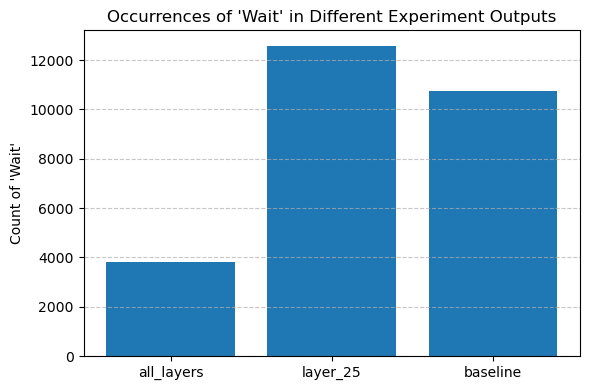

In [17]:
import matplotlib.pyplot as plt

# Plot
plt.figure(figsize=(6, 4))
plt.bar(counts.keys(), counts.values())
plt.ylabel("Count of 'Wait'")
plt.title("Occurrences of 'Wait' in Different Experiment Outputs")
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [16]:
import re

# Regex pattern to extract content inside \boxed{...}
# boxed_pattern = re.compile(r"\\boxed\{(.*?)\}")
def extract_all_boxed_balanced(text):
    if not isinstance(text, str):
        return []

    matches = []
    idx = 0

    while True:
        start = text.find(r'\boxed{', idx)
        if start == -1:
            break

        i = start + len(r'\boxed{')
        brace_count = 1
        content_chars = []

        while i < len(text) and brace_count > 0:
            char = text[i]
            if char == '{':
                brace_count += 1
            elif char == '}':
                brace_count -= 1

            if brace_count > 0:
                content_chars.append(char)
            i += 1

        if brace_count == 0:
            matches.append(''.join(content_chars).strip())
        else:
            # Unmatched braces — invalid boxed expression
            break

        idx = i

    return matches
    

def extract_last_boxed_balanced(text):
    matches = extract_all_boxed_balanced(text)
    return matches[-1] if matches else None

# Apply and rename columns accordingly
all_layers_df["all_layers_answer"] = all_layers_df["all_layers"].apply(extract_last_boxed_balanced)
layer_19_df["layer_19_answer"] = layer_19_df["layer_19"].apply(extract_last_boxed_balanced)
baseline_df["baseline_answer"] = baseline_df["baseline"].apply(extract_last_boxed_balanced)


In [57]:
baseline_df["baseline"][0]

'Problem 6. Calculate the maximum number of distinct real roots that a polynomial $P$ can have, which satisfies the following property: the product of two distinct roots of $P$ is still a root of $P$.\nPlease reason step by step, and put your final answer within \\boxed{}.\nAlright, so I came across this interesting problem today. It goes like this: "Calculate the maximum number of distinct real roots that a polynomial \\( P \\) can have, which satisfies the following property: the product of two distinct roots of \\( P \\) is still a root of \\( P \\)." Hmm, okay, let me try to figure this out step by step.\n\nFirst, let me make sure I understand the problem correctly. We need to find the maximum number of distinct real roots a polynomial \\( P \\) can have, given that for any two distinct roots \\( r_1 \\) and \\( r_2 \\) of \\( P \\), their product \\( r_1 \\times r_2 \\) is also a root of \\( P \\). So, \\( P \\) must be such that multiplying any two distinct roots gives another ro

In [18]:
from datasets import load_dataset

# Load the dataset (this may take a bit of time the first time)
dataset = load_dataset("open-r1/OpenR1-Math-220k", split="train")

# Convert to pandas DataFrame
openr1_df = dataset.to_pandas()



In [19]:
print(openr1_df.columns)


Index(['problem', 'solution', 'answer', 'problem_type', 'question_type',
       'source', 'uuid', 'is_reasoning_complete', 'generations',
       'correctness_math_verify', 'correctness_llama', 'finish_reasons',
       'correctness_count', 'messages'],
      dtype='object')


In [31]:
len( all_layers_df)

51

In [32]:
len(combined_df)

711

In [33]:
# Are there duplicated uuids in openr1_df?
print("Duplicates in openr1_df:", openr1_df["uuid"].duplicated().sum())


Duplicates in openr1_df: 722


In [34]:
# Group by uuid and count number of unique answers for each group
inconsistencies = openr1_df.groupby("uuid")["answer"].nunique()

# Filter to only those with more than 1 unique answer
inconsistent_uuids = inconsistencies[inconsistencies > 1]

# Filter to only those with more than 1 unique answer
inconsistent_uuids = inconsistencies[inconsistencies > 1]

print(f"Number of duplicated uuids with inconsistent answers: {len(inconsistent_uuids)}")

# Optionally display a few for inspection
openr1_df[openr1_df["uuid"].isin(inconsistent_uuids.index)].sort_values("uuid").head(10)


Number of duplicated uuids with inconsistent answers: 9


,problem,solution,answer,problem_type,question_type,source,uuid,is_reasoning_complete,generations,correctness_math_verify,correctness_llama,finish_reasons,correctness_count,messages
6388,10.1. Find the smallest of the solutions to th...,Answer: $-13-\sqrt{57} \approx-20.55$.\n\nSolu...,-13-\sqrt{57},Inequalities,math-word-problem,olympiads,044abab2-997e-58b2-9c29-1fca20d22641,"[False, True]","[<think>\nOkay, so I need to find the smallest...","[False, True]",None,"[length, stop]",1,[{'content': '10.1. Find the smallest of the s...
23402,10.1. Find the smallest solution of the inequa...,Answer: $-13-\sqrt{57} \approx-20.55$.\n\nSolu...,-13-\sqrt{57}\approx-20.55,Inequalities,math-word-problem,olympiads,044abab2-997e-58b2-9c29-1fca20d22641,"[False, True]","[<think>\nOkay, so I need to solve this inequa...","[False, True]",None,"[length, stop]",1,[{'content': '10.1. Find the smallest solution...
80208,## Task A-1.4.\n\nLet $D$ be the foot of the a...,## Second Solution.\n\nLet point $G$ be the mi...,\frac{1}{3},Geometry,math-word-problem,olympiads,15b5ce06-ce44-5abd-96f4-0d3ab28a4dff,"[True, True]","[<think>\nOkay, so I need to find the ratio of...","[True, True]",None,"[stop, stop]",2,[{'content': '## Task A-1.4. Let $D$ be the f...
44563,## Zadatak A-1.4.\n\nNeka je $D$ nožište visin...,## Prvo rješenje.\n\nNeka je točka $F$ poloviš...,|CE|:|AC|=1:3,Geometry,math-word-problem,olympiads,15b5ce06-ce44-5abd-96f4-0d3ab28a4dff,"[True, True]","[<think>\nOkay, let's see. I have this geometr...","[True, True]",None,"[stop, stop]",2,[{'content': '## Zadatak A-1.4. Neka je $D$ n...
54176,## Zadatak B-1.7.\n\nDva pravokutna trokuta $P...,## Prvo rješenje.\n\n![](https://cdn.mathpix.c...,\frac{39}{5}\mathrm{~}^{2},Geometry,math-word-problem,olympiads,1be7c80e-f860-57ca-92e3-6e651904f068,"[True, True]","[<think>\nOkay, so I have this geometry proble...","[True, True]",None,"[stop, stop]",2,[{'content': '## Zadatak B-1.7. Dva pravokutn...
50398,## Task B-1.7.\n\nTwo right triangles $P S T$ ...,## Second Solution.\n\nUsing the same notation...,\frac{39}{5},Geometry,math-word-problem,olympiads,1be7c80e-f860-57ca-92e3-6e651904f068,"[True, True]","[<think>\nOkay, let me try to figure out this ...","[True, True]",None,"[stop, stop]",2,[{'content': '## Task B-1.7. Two right triang...
2474,## Task B-4.7.\n\nDetermine all natural number...,## Second Solution.\n\nThe condition for solvi...,1<x<\sqrt{2017},Inequalities,math-word-problem,olympiads,3ae81009-6c5a-513d-a1d5-e40cfb1410fe,"[True, True]","[<think>\nOkay, let's tackle this problem step...","[False, False]","[True, True]",None,2,[{'content': '## Task B-4.7. Determine all na...
63743,## Zadatak B-4.7.\n\nOdredite sve prirodne bro...,## Prvo rješenje.\n\nUvjet za rješenje zadatka...,"x\in{2,3,4,5,6,\ldots,44}",Inequalities,math-word-problem,olympiads,3ae81009-6c5a-513d-a1d5-e40cfb1410fe,"[True, True]","[<think>\nOkay, let's try to solve this inequa...","[False, False]","[False, True]",None,1,[{'content': '## Zadatak B-4.7. Odredite sve ...
66381,## Task B-1.5.\n\nDetermine all three-digit nu...,## Second solution.\n\nLet $x=\overline{a b c}...,"243,972",Number Theory,math-word-problem,olympiads,40298ed5-29bf-5f81-aecc-02859da7e53f,"[True, True]","[<think>\nOkay, so I need to find all three-di...","[False, False]","[True, False]",None,1,[{'content': '## Task B-1.5. Determine all th...
33131,## Zadatak B-1.5.\n\nOdredite sve troznamenkas...,## Prvo rješenje.\n\nNeka je $x=\overline{a b ...,243972,Number Theory,math-word-problem,olympiads,40298ed5-29bf-5f81-aecc-02859da7e53f,"[True, True]","[<think>\nOkay, so I need to find all three-di...","[False, False]","[True, False]",None,1,[{'content': '## Zadatak B-1.5. Odredite sve ...


In [35]:
# Identify UUIDs where answer is consistent
uuid_counts = openr1_df.groupby("uuid")["answer"].nunique()
consistent_uuids = uuid_counts[uuid_counts == 1].index

# Filter openr1_df to only those consistent UUIDs
openr1_df_clean = openr1_df[openr1_df["uuid"].isin(consistent_uuids)].drop_duplicates(subset="uuid")


In [36]:
combined_df = all_layers_df[["uuid", "all_layers_answer", "input_text"]].merge(
    layer_19_df[["uuid", "layer_19_answer"]], on="uuid", how="inner"
).merge(
    baseline_df[["uuid", "baseline_answer"]], on="uuid", how="inner"
)

combined_df = combined_df.merge(openr1_df_clean[["uuid", "answer"]], on="uuid", how="left")


# # Add ground-truth answer from OpenR1
# combined_df = combined_df.merge(openr1_df[["uuid", "answer"]], on="uuid", how="left")




In [37]:
len(combined_df)

51

In [64]:
combined_df

,uuid,all_layers_answer,input_text,layer_19_answer,baseline_answer,answer,all_layers_answer_wrapped,baseline_answer_wrapped,gold_wrapped,all_layers_correct,baseline_correct
0,270eba43-86d3-570c-a80c-b09965d3af04,3,Problem 6. Calculate the maximum number of dis...,3,,4,$3$,$$,$4$,False,False
1,9c45cbde-7fcd-5084-b9e3-2549e4ad4263,45^\circ,7. Quadrilateral $ABCD$ is inscribed in a circ...,45^\circ,,")r=\sqrt{6},b)\angleBDC=30",$45^\circ$,$$,"$)r=\sqrt{6},b)\angleBDC=30$",False,False
2,16b28ea3-e7d0-5078-83f3-072e06691981,1,"Example 8. In a Go tournament, ten players par...",1,,"8.5, 8, 6.5, 6, 5.5, 4.5",$1$,$$,"$8.5, 8, 6.5, 6, 5.5, 4.5$",False,False
3,56ce2401-2a44-5a8c-82a5-c360501da611,12,5. Determine the unknown number $x$ and explai...,12,,12,$12$,$$,$12$,False,False
4,84069839-69d4-5f34-80a4-754aa4cf15bc,"[-1, 1 + \sqrt{3}]","2. If real numbers $x, y$ satisfy $x^{2}+2 \co...","[-1, 1 + \sqrt{3}]","[-1, 1 + \sqrt{3}]","[-1,\sqrt{3}+1]","$[-1, 1 + \sqrt{3}]$","$[-1, 1 + \sqrt{3}]$","$[-1,\sqrt{3}+1]$",False,False
5,a36682ed-1be9-59e6-a531-89b96e95c7c7,B,Five students ran a race. Ryan was faster than...,B,A,A,$B$,$A$,$A$,False,False
6,bc44b812-5291-5df9-97ca-ec0b452ad349,45; 150,"1. For two consecutive days, Petya went to the...",45; 150,45; 150,150;45,$45; 150$,$45; 150$,$150;45$,False,False
7,f9123cba-545a-5269-bf6f-5c0387e681ad,9,\nN2. Find the maximum number of natural numbe...,9,,10,$9$,$$,$10$,False,False
8,d6951627-dd38-5be8-84cb-aff60dfc6388,20,1. (16 points) The dividend is five times larg...,20,100,100,$20$,$100$,$100$,False,False
9,2ae00eaa-8c98-5984-a642-1a46feda014c,,# Problem № 7 (10 points)\n\nIn the electrical...,,,10\Omega,$$,$$,$10\Omega$,False,False


In [63]:
combined_df.to_parquet("bedrock_sample.parquet", index=False)

In [38]:
layer_19_df["layer_19_answer"][0]

'3'

In [39]:
# Find rows where all_layers and baseline disagree
mismatches = combined_df["all_layers_answer"] != combined_df["baseline_answer"]

# Create a DataFrame with the mismatched answers + ground truth
diff_df = combined_df.loc[mismatches, [
    "uuid",
    "all_layers_answer",
    "baseline_answer",
    "layer_19_answer",       # optional, but useful
    "answer",                # raw ground truth from OpenR1
]]

print(f"Total differing rows: {len(diff_df)}")
display(diff_df)



Total differing rows: 28


,uuid,all_layers_answer,baseline_answer,layer_19_answer,answer
0,270eba43-86d3-570c-a80c-b09965d3af04,3,,3,4
1,9c45cbde-7fcd-5084-b9e3-2549e4ad4263,45^\circ,,45^\circ,")r=\sqrt{6},b)\angleBDC=30"
2,16b28ea3-e7d0-5078-83f3-072e06691981,1,,1,"8.5, 8, 6.5, 6, 5.5, 4.5"
3,56ce2401-2a44-5a8c-82a5-c360501da611,12,,12,12
5,a36682ed-1be9-59e6-a531-89b96e95c7c7,B,A,B,A
7,f9123cba-545a-5269-bf6f-5c0387e681ad,9,,9,10
8,d6951627-dd38-5be8-84cb-aff60dfc6388,20,100,20,100
10,c23faabd-b4ec-522b-8aa6-d86ca711901b,,\frac{1}{2},,\frac{BM}{MC} = \frac{1}{2}
13,29d2ec6e-ad42-57b3-a808-33da6ed26817,B,A,B,C
15,8277c3fd-722e-5572-b3e3-74753b11310e,"(0, -17)","(-2, 35)","(0, -17)","(x,y)=(0,-17),(2,35),(-2,35),(4,-1),(-4,-1)"


In [45]:
# def wrap_math(text):
#     if text and not text.strip().startswith("$"):
#         return f"${text.strip()}$"
#     return text

# def wrap_math(text):
#     if isinstance(text, str) and not text.strip().startswith("$"):
#         return f"${text.strip()}$"
#     return text

def wrap_math(text):
    if isinstance(text, str):
        stripped = text.strip()
        if not stripped.startswith("$"):
            return f"${stripped}$"
        return stripped
    return "wrong"



combined_df["all_layers_answer_wrapped"] = combined_df["all_layers_answer"].apply(wrap_math)
combined_df["baseline_answer_wrapped"] = combined_df["baseline_answer"].apply(wrap_math)
combined_df["gold_wrapped"] = combined_df["answer"].apply(wrap_math)


In [56]:
combined_df.columns

Index(['uuid', 'all_layers_answer', 'input_text', 'layer_19_answer',
       'baseline_answer', 'answer', 'all_layers_answer_wrapped',
       'baseline_answer_wrapped', 'gold_wrapped', 'all_layers_correct',
       'baseline_correct'],
      dtype='object')

In [61]:
index = 4
combined_df["all_layers_answer_wrapped"][index],  combined_df["gold_wrapped"][index], combined_df["baseline_answer_wrapped"] [index]

('$[-1, 1 + \\sqrt{3}]$', '$[-1,\\sqrt{3}+1]$', '$[-1, 1 + \\sqrt{3}]$')

In [47]:
# from math_verify import parse, verify, LatexExtractionConfig
from math_verify import verify
def is_equivalent(pred, gold):
    try:
        parsed_pred = parse(pred, extraction_config=[LatexExtractionConfig()])
        parsed_gold = parse(gold, extraction_config=[LatexExtractionConfig()])
        return verify(parsed_gold, parsed_pred)
    except Exception:
        return False  # fallback if parsing fails

# Evaluate both model predictions
combined_df["all_layers_correct"] = combined_df.apply(
    lambda row: is_equivalent(row["all_layers_answer_wrapped"], row["gold_wrapped"]),
    axis=1
)

combined_df["baseline_correct"] = combined_df.apply(
    lambda row: is_equivalent(row["baseline_answer_wrapped"], row["gold_wrapped"]),
    axis=1
)


In [48]:
combined_df["all_layers_correct"].value_counts()

all_layers_correct
False    51
Name: count, dtype: int64

In [49]:
combined_df["baseline_correct"].value_counts()

baseline_correct
False    51
Name: count, dtype: int64